In [7]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

!pip install lightgbm
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from config.settings import MYSQL_URI
from sqlalchemy import create_engine

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

print("Başarıyla bağlandık ve XGBoost hazır!")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Başarıyla bağlandık ve XGBoost hazır!


In [2]:
engine = create_engine(MYSQL_URI)
df = pd.read_sql("customers", engine)
X = df.drop("churn", axis=1)
y = df["churn"]
model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

age                 0.218906
products_number     0.125121
balance             0.121470
estimated_salary    0.119466
customer_id         0.119213
credit_score        0.116825
tenure              0.070769
active_member       0.038343
country_Germany     0.020649
credit_card         0.016051
country_France      0.009583
country_Spain       0.008189
gender_Male         0.007885
gender_Female       0.007531
dtype: float64


In [12]:
X = df.drop(["churn","customer_id"], axis=1)
y = df["churn"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<15} | {'CV Mean AUC':<12} | {'CV Std':<8}")
print("-" * 45)

for name, model in models.items():

    fold_scores = []

    for train_idx, val_idx in kf.split(X_train_val):

        # fold split
        X_train_fold = X_train_val.iloc[train_idx]
        X_val_fold   = X_train_val.iloc[val_idx]

        y_train_fold = y_train_val.iloc[train_idx]
        y_val_fold   = y_train_val.iloc[val_idx]

        # scaler sadece train fold'a fit edilir
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled   = scaler.transform(X_val_fold)

        # modeli fit et
        model.fit(X_train_fold_scaled, y_train_fold)

        # validation AUC
        val_probs = model.predict_proba(X_val_fold_scaled)[:, 1]
        fold_scores.append(roc_auc_score(y_val_fold, val_probs))

    print(f"{name:<15} | {np.mean(fold_scores):.4f}     | {np.std(fold_scores):.4f}")


Model           | CV Mean AUC  | CV Std  
---------------------------------------------
XGBoost         | 0.8584     | 0.0116
[LightGBM] [Info] Number of positive: 1317, number of negative: 5083
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205781 -> initscore=-1.350545
[LightGBM] [Info] Start training from score -1.350545


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1297, number of negative: 5103
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202656 -> initscore=-1.369775
[LightGBM] [Info] Start training from score -1.369775
[LightGBM] [Info] Number of positive: 1321, number of negative: 5079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000576 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.206406 -> initscore=-1.346725
[LightGBM] [Info] Start training from score -1.346725


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1300, number of negative: 5100
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203125 -> initscore=-1.366876
[LightGBM] [Info] Start training from score -1.366876
[LightGBM] [Info] Number of positive: 1341, number of negative: 5059
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.209531 -> initscore=-1.327753
[LightGBM]

c:\Users\melis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        | 0.8569     | 0.0151
Random Forest   | 0.8483     | 0.0067


[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 869
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205500 -> initscore=-1.352267
[LightGBM] [Info] Start training from score -1.352267


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


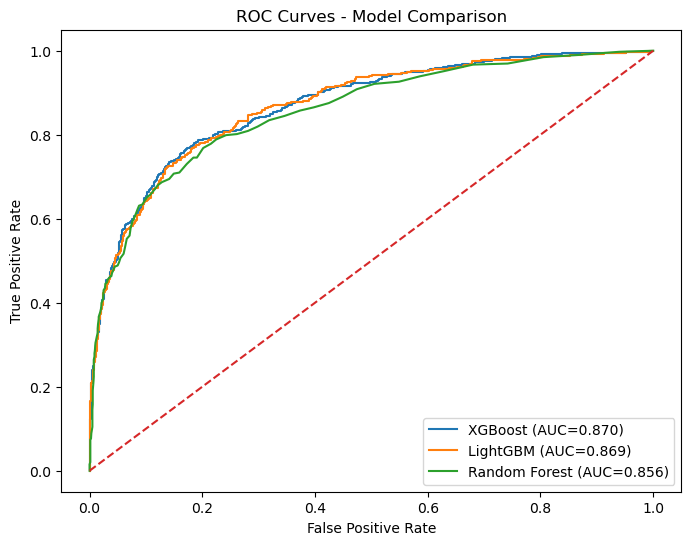

In [13]:
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

final_results = {}
plt.figure(figsize=(8, 6))

for name, model in models.items():

    model.fit(X_train_val_scaled, y_train_val)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, probs)
    final_results[name] = auc

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curves - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


#TRUE POSITIVE RATE : Gerçek churn olanların yüzde kaçı doğru yakalandı?
#FALSE POSITIVE RATE : Churn olmayanlardan kaçını yanlış churn dedik?



In [14]:
import joblib
import os

if not os.path.exists('models'):
    os.makedirs('models')

for name, model in models.items():
    model.fit(X_train_val_scaled, y_train_val)

    file_name = f"models/{name.lower().replace(' ', '_')}_model.pkl"
    
    joblib.dump(model, file_name)
    print(f"{name} başarıyla kaydedildi: {file_name}")

joblib.dump(scaler, "models/scaler.pkl")
print("Scaler başarıyla kaydedildi: models/scaler.pkl")

XGBoost başarıyla kaydedildi: models/xgboost_model.pkl
[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 869
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205500 -> initscore=-1.352267
[LightGBM] [Info] Start training from score -1.352267
LightGBM başarıyla kaydedildi: models/lightgbm_model.pkl
Random Forest başarıyla kaydedildi: models/random_forest_model.pkl
Scaler başarıyla kaydedildi: models/scaler.pkl
